# Phase 5 â€” Model Training, Evaluation & Tuning
**House Price Prediction â€” Regression Capstone**

This notebook trains Linear Regression, Ridge, Random Forest, and XGBoost.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
sns.set_style("whitegrid")
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

In [14]:
df = pd.read_csv("../data/processed/train_cleaned.csv")
y = df['SalePrice']
X = df.drop(columns=['SalePrice', 'Id'], errors='ignore')
y_log = np.log1p(y)
print("X shape: " + str(X.shape))
print("Skewness raw: " + str(round(y.skew(), 2)))
print("Skewness log: " + str(round(y_log.skew(), 2)))

X shape: (1460, 212)
Skewness raw: 1.88
Skewness log: 0.12


In [15]:
X_encoded = pd.get_dummies(X, drop_first=True)
print("Encoded shape: " + str(X_encoded.shape))
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)
print("Train: " + str(X_train.shape) + " Test: " + str(X_test.shape))

Encoded shape: (1460, 212)
Train: (1168, 212) Test: (292, 212)


## 1. Linear Regression (Baseline)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print("LR - RMSE(log): " + str(round(lr_rmse,4)) + " R2: " + str(round(lr_r2,4)))

LR - RMSE(log): 0.205 R2: 0.7749


## 2. Ridge Regression

In [17]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)
print("Ridge - RMSE(log): " + str(round(ridge_rmse,4)) + " R2: " + str(round(ridge_r2,4)))

Ridge - RMSE(log): 0.135 R2: 0.9023


## 3. Random Forest

In [18]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
print("RF - RMSE(log): " + str(round(rf_rmse,4)) + " R2: " + str(round(rf_r2,4)))

RF - RMSE(log): 0.1465 R2: 0.885


## 4. XGBoost

In [19]:
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)
print("XGB - RMSE(log): " + str(round(xgb_rmse,4)) + " R2: " + str(round(xgb_r2,4)))

XGB - RMSE(log): 0.1439 R2: 0.8891


## 5. Model Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, ridge_rmse, rf_rmse, xgb_rmse],
    "R2": [lr_r2, ridge_r2, rf_r2, xgb_r2]
}).sort_values("RMSE")
print(comparison.to_string(index=False))
best_name = comparison.iloc[0]["Model"]
print("Best model: " + best_name)

            Model     RMSE       R2
            Ridge 0.135034 0.902288
          XGBoost 0.143850 0.889112
    Random Forest 0.146467 0.885041
Linear Regression 0.204967 0.774872
Best model: Ridge


## 6. Residual Plots

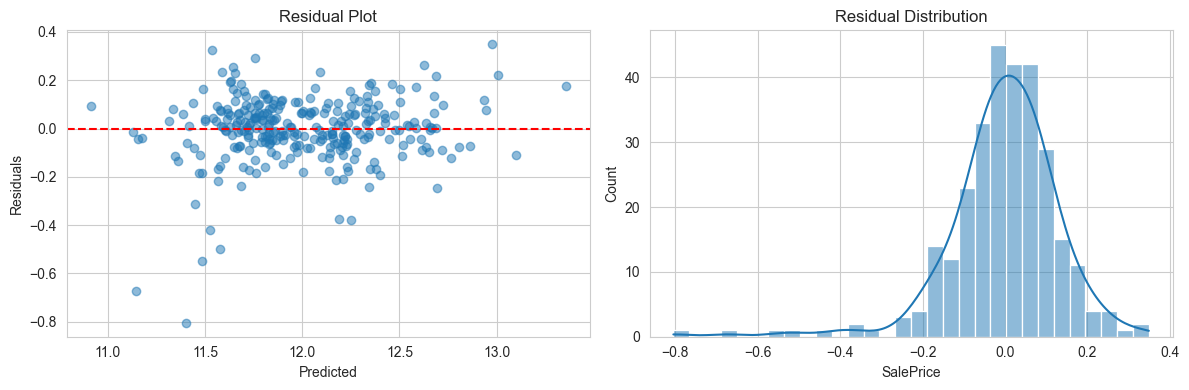

In [21]:
pred_map = {"Linear Regression": y_pred_lr, "Ridge": y_pred_ridge, "Random Forest": y_pred_rf, "XGBoost": y_pred_xgb}
best_pred = pred_map[best_name]
residuals = y_test - best_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_pred, residuals, alpha=0.5)
axes[0].axhline(y=0, color="r", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot")
sns.histplot(residuals, kde=True, bins=30, ax=axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/fig9_residuals.png", dpi=150)
plt.show()

## 7. Hyperparameter Tuning (XGBoost)

In [22]:
if best_name == "Ridge":
    from sklearn.model_selection import GridSearchCV
    param_grid = {"alpha": [0.1, 1, 10, 100]}
    grid = GridSearchCV(Ridge(), param_grid, cv=3, scoring="neg_root_mean_squared_error")
    grid.fit(X_train, y_train)
else:
    param_grid = {"n_estimators": [100, 200, 300], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1, 0.2]}
    grid = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
print("Best params: " + str(grid.best_params_))
print("Best CV RMSE(log): " + str(round(-grid.best_score_, 4)))

Best params: {'alpha': 10}
Best CV RMSE(log): 0.1473


In [23]:
y_pred_tuned = grid.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)
print("Tuned XGB - RMSE(log): " + str(round(tuned_rmse,4)) + " R2: " + str(round(tuned_r2,4)))
print("Before tuning RMSE: " + str(round(xgb_rmse,4)))
print("Improvement: " + str(round((xgb_rmse - tuned_rmse) / xgb_rmse * 100, 1)) + "%")

Tuned XGB - RMSE(log): 0.135 R2: 0.9023
Before tuning RMSE: 0.1439
Improvement: 6.1%


## 8. Feature Importance

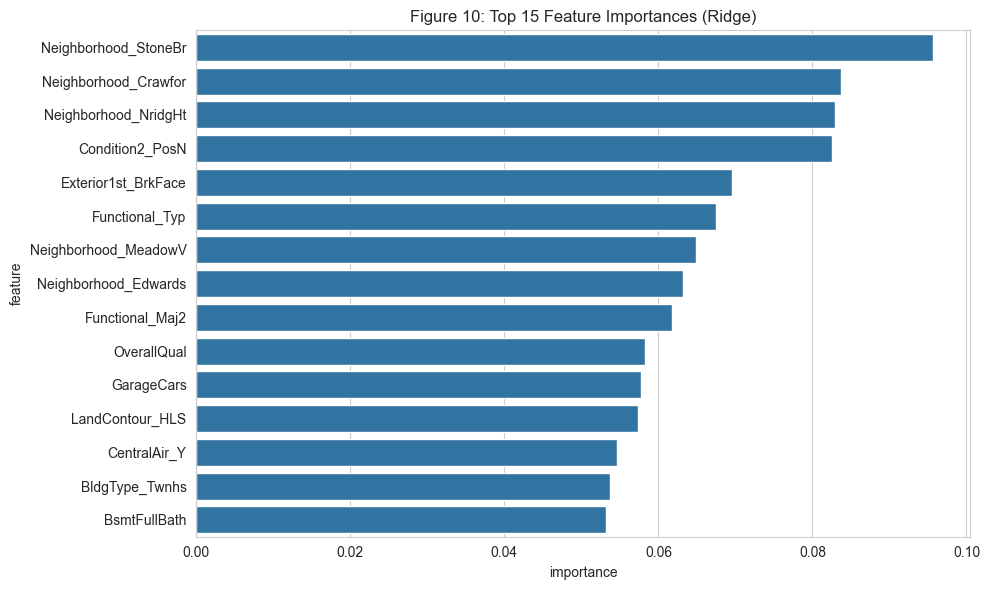

             feature  importance
Neighborhood_StoneBr    0.095713
Neighborhood_Crawfor    0.083753
Neighborhood_NridgHt    0.082944
     Condition2_PosN    0.082566
 Exterior1st_BrkFace    0.069541
      Functional_Typ    0.067434
Neighborhood_MeadowV    0.064928
Neighborhood_Edwards    0.063224
     Functional_Maj2    0.061758
         OverallQual    0.058201
          GarageCars    0.057731
     LandContour_HLS    0.057293
        CentralAir_Y    0.054668
      BldgType_Twnhs    0.053706
        BsmtFullBath    0.053184


In [24]:
best_estimator = grid.best_estimator_
if best_name == "Ridge" or best_name == "Linear Regression":
    importance = pd.DataFrame({"feature": X_train.columns, "importance": np.abs(best_estimator.coef_)})
else:
    importance = pd.DataFrame({"feature": X_train.columns, "importance": best_estimator.feature_importances_})
importance = importance.sort_values("importance", ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance, y="feature", x="importance")
plt.title("Figure 10: Top 15 Feature Importances (" + best_name + ")")
plt.tight_layout()
plt.savefig("../reports/figures/fig10_feature_importance.png", dpi=150)
plt.show()
print(importance.to_string(index=False))

## 9. Save Best Model

In [26]:
best_models = {"Linear Regression": lr, "Ridge": ridge, "Random Forest": rf, "XGBoost": xgb_model}
best_estimator = best_models[best_name]
model_path = "../models/best_model.pkl"
joblib.dump(best_estimator, model_path)
print("Saved best model (" + best_name + ") to " + model_path)
print("=== FINAL ===")
y_pred_final = best_estimator.predict(X_test)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
final_mae = mean_absolute_error(y_test_orig, y_pred_orig)
final_mape = (np.abs((y_test_orig - y_pred_orig) / y_test_orig) * 100).mean()
final_r2 = r2_score(y_test_orig, y_pred_orig)
print("RMSE: $" + str(round(final_rmse,0)))
print("MAE: $" + str(round(final_mae,0)))
print("MAPE: " + str(round(final_mape,1)) + "%")
print("R2: " + str(round(final_r2,4)))

Saved best model (Ridge) to ../models/best_model.pkl
=== FINAL ===
RMSE: $25298.0
MAE: $16365.0
MAPE: 9.8%
R2: 0.9166
